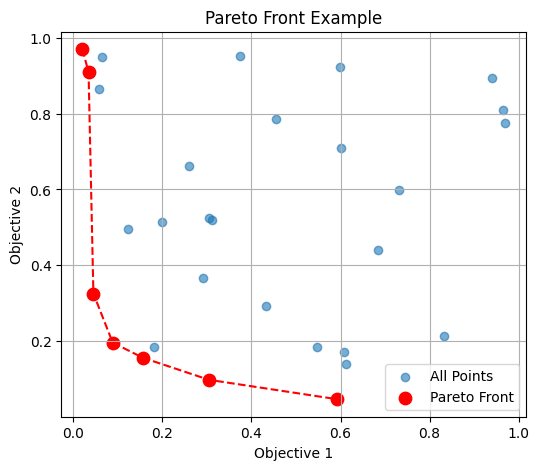

Pareto front indices: [ 2  5 14 18 21 28 29]
Pareto front points:
 [[0.15601864 0.15599452]
 [0.02058449 0.96990985]
 [0.59241457 0.04645041]
 [0.30461377 0.09767211]
 [0.03438852 0.9093204 ]
 [0.0884925  0.19598286]
 [0.04522729 0.32533033]]


In [5]:
# Pareto Front Calculation and Visualization in Python
import numpy as np
import matplotlib.pyplot as plt

def pareto_front(points):
    """
    Compute Pareto front indices from a set of points.
    
    Parameters:
        points (ndarray): Shape (n_points, n_objectives)
    
    Returns:
        front_indices (list): Indices of Pareto-optimal points
    """
    if not isinstance(points, np.ndarray):
        raise TypeError("Input must be a NumPy array.")
    if points.ndim != 2:
        raise ValueError("Input must be a 2D array of shape (n_points, n_objectives).")
    if points.shape[0] == 0:
        return []

    num_points = points.shape[0]
    is_dominated = np.zeros(num_points, dtype=bool)

    for i in range(num_points):
        for j in range(num_points):
            if i != j:
                # Check if point j dominates point i
                if np.all(points[j] <= points[i]) and np.any(points[j] < points[i]):
                    is_dominated[i] = True
                    break

    return np.where(~is_dominated)[0]

# Example: 2D Pareto front
np.random.seed(42)
data = np.random.rand(30, 2)  # 30 points, 2 objectives

# Get Pareto front indices
front_idx = pareto_front(data)
pareto_points = data[front_idx]

# Plot results
plt.figure(figsize=(6, 5))
plt.scatter(data[:, 0], data[:, 1], label="All Points", alpha=0.6)
plt.scatter(pareto_points[:, 0], pareto_points[:, 1], color="red", label="Pareto Front", s=80)
plt.plot(pareto_points[np.argsort(pareto_points[:, 0])][:, 0],
         pareto_points[np.argsort(pareto_points[:, 0])][:, 1],
         color="red", linestyle="--")
plt.xlabel("Objective 1")
plt.ylabel("Objective 2")
plt.title("Pareto Front Example")
plt.legend()
plt.grid(True)
plt.show()

print("Pareto front indices:", front_idx)
print("Pareto front points:\n", pareto_points)


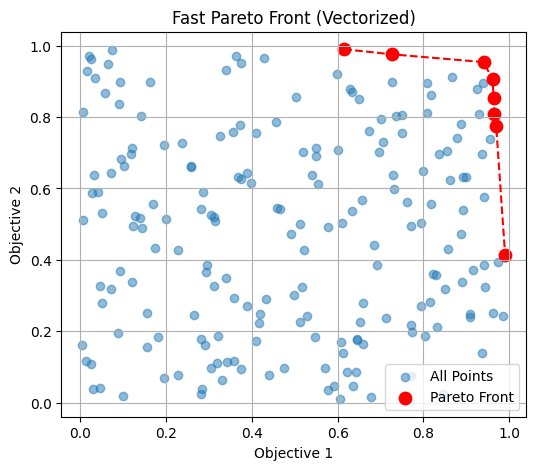

Pareto front size (10k points): 9


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def pareto_front_fast(points):
    """
    Fast Pareto front computation using NumPy broadcasting.
    
    Parameters:
        points (ndarray): Shape (n_points, n_objectives)
    
    Returns:
        front_indices (ndarray): Indices of Pareto-optimal points
    """
    if not isinstance(points, np.ndarray):
        raise TypeError("Input must be a NumPy array.")
    if points.ndim != 2:
        raise ValueError("Input must be a 2D array of shape (n_points, n_objectives).")
    if points.shape[0] == 0:
        return np.array([], dtype=int)

    # Compare all points against each other
    less_equal = np.all(points[:, None] <= points[None, :], axis=2)
    strictly_less = np.any(points[:, None] < points[None, :], axis=2)

    # A point is dominated if another point is <= in all objectives and < in at least one
    dominated = np.any(less_equal & strictly_less, axis=1)

    return np.where(~dominated)[0]

# Example: Large dataset
np.random.seed(42)
data = np.random.rand(10000, 2)  # 10k points, 2 objectives

# Compute Pareto front
front_idx = pareto_front_fast(data)
pareto_points = data[front_idx]

# Plot only for small datasets (avoid plotting 10k points for speed)
sample_data = data[:200]
sample_front_idx = pareto_front_fast(sample_data)
sample_pareto_points = sample_data[sample_front_idx]

plt.figure(figsize=(6, 5))
plt.scatter(sample_data[:, 0], sample_data[:, 1], alpha=0.5, label="All Points")
plt.scatter(sample_pareto_points[:, 0], sample_pareto_points[:, 1], color="red", s=80, label="Pareto Front")
plt.plot(sample_pareto_points[np.argsort(sample_pareto_points[:, 0])][:, 0],
         sample_pareto_points[np.argsort(sample_pareto_points[:, 0])][:, 1],
         color="red", linestyle="--")
plt.xlabel("Objective 1")
plt.ylabel("Objective 2")
plt.title("Fast Pareto Front (Vectorized)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Pareto front size (10k points): {len(front_idx)}")


In [12]:
def f1(x):
    return x
def f2(x):
    return 1 - x**2 + 4*(x-1.5)**3

for x in np.arange(0, 2.1, 0.4):
    print(f"x: {x:.2f}, f1: {f1(x):.2f}, f2: {f2(x):.2f}")

x: 0.00, f1: 0.00, f2: -12.50
x: 0.40, f1: 0.40, f2: -4.48
x: 0.80, f1: 0.80, f2: -1.01
x: 1.20, f1: 1.20, f2: -0.55
x: 1.60, f1: 1.60, f2: -1.56
x: 2.00, f1: 2.00, f2: -2.50


s -> A -> C -> t
s -> A -> C -> B -> t
s -> A -> C -> B -> D -> t
s -> A -> C -> D -> t
s -> A -> B -> t
s -> A -> B -> D -> t
s -> A -> E -> C -> t
s -> A -> E -> C -> B -> t
s -> A -> E -> C -> B -> D -> t
s -> A -> E -> C -> D -> t
s -> B -> t
s -> B -> D -> t
s -> E -> C -> t
s -> E -> C -> B -> t
s -> E -> C -> B -> D -> t
s -> E -> C -> D -> t

Total paths: 16
Path: s -> A -> C -> t, Time: 24, Distance: 7
Path: s -> A -> C -> B -> t, Time: 27, Distance: 12
Path: s -> A -> C -> B -> D -> t, Time: 27, Distance: 16
Path: s -> A -> C -> D -> t, Time: 26, Distance: 11
Path: s -> A -> B -> t, Time: 20, Distance: 11
Path: s -> A -> B -> D -> t, Time: 20, Distance: 15
Path: s -> A -> E -> C -> t, Time: 24, Distance: 9
Path: s -> A -> E -> C -> B -> t, Time: 27, Distance: 14
Path: s -> A -> E -> C -> B -> D -> t, Time: 27, Distance: 18
Path: s -> A -> E -> C -> D -> t, Time: 26, Distance: 13
Path: s -> B -> t, Time: 12, Distance: 12
Path: s -> B -> D -> t, Time: 12, Distance: 16
Path: s -

Text(0, 0.5, 'Distance')

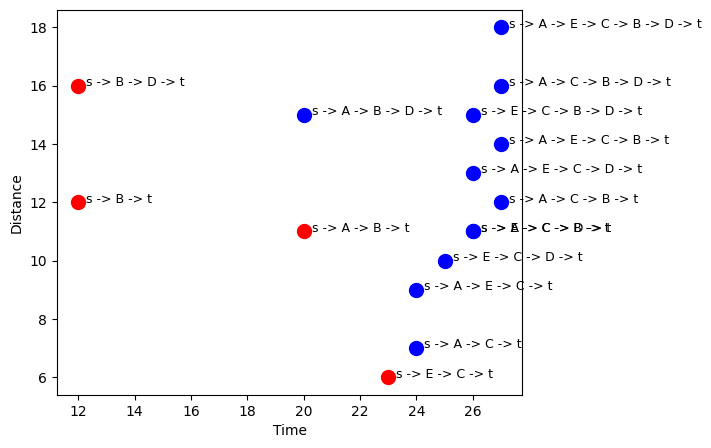

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def enumerate_paths(network, start, end):
    all_paths = []
    
    def dfs(current, path, visited):
        if current == end:
            all_paths.append(tuple(path))
            return
        
        for (u, v) in network:
            if u == current and v not in visited:
                dfs(v, path + [v], visited | {v})
    
    dfs(start, [start], {start})
    return all_paths



# Network: each link is (from, to): (time, distance)
network = {
    ('s', 'A'): (7, 2),
    ('s', 'B'): (5, 8),
    ('s', 'E'): (10, 1),   # very slow, very short
    ('A', 'C'): (9, 3),
    ('A', 'B'): (6, 5),
    ('A', 'E'): (4, 2),
    ('B', 't'): (7, 4),
    ('B', 'D'): (3, 6),    # fast, long
    ('C', 't'): (8, 2),
    ('C', 'B'): (4, 3),
    ('C', 'D'): (6, 4),
    ('D', 't'): (4, 2),    # fast, short
    ('E', 'C'): (5, 3),
}

# Enumerate paths from s to t
paths = enumerate_paths(network, 's', 't')
for p in paths:
    print(' -> '.join(p))
print(f"\nTotal paths: {len(paths)}")


path_metrics = {path: {'time': 0, 'distance': 0} for path in paths}


# TODO: for each path, compute total time and total distance
# Hint: zip consecutive nodes to get links, look them up in network
for path in paths:
    for link in zip(path, path[1:]):
        time, distance = network[link]
        path_metrics[path]['time'] += time
        path_metrics[path]['distance'] += distance
    print(f"Path: {' -> '.join(path)}, Time: {path_metrics[path]['time']}, Distance: {path_metrics[path]['distance']}")


# TODO: identify which paths are Pareto optimal
# Hint: a path is dominated if another path is better in both time AND distance
pareto_optimal_paths = []
for path in paths:
    dominated = False
    for other_path in paths:
        if path != other_path:
            if (path_metrics[other_path]['time'] < path_metrics[path]['time'] and
                path_metrics[other_path]['distance'] < path_metrics[path]['distance']):
                dominated = True
                break
    if not dominated:
        pareto_optimal_paths.append(path)
print(pareto_optimal_paths)


# TODO: plot all paths in objective space (time vs distance)
# mark Pareto optimal points differently from dominated ones
plt.figure(figsize=(6,5))
for path in paths:
    time = path_metrics[path]['time']
    distance = path_metrics[path]['distance']
    if path in pareto_optimal_paths:
        plt.scatter(time, distance, color='red', s=100, label='Pareto Optimal' if 'Pareto Optimal' not in plt.gca().get_legend_handles_labels()[1] else "")
        plt.text(time, distance, '  ' + ' -> '.join(path), fontsize=9)
    else:
        plt.scatter(time, distance, color='blue', s=100, label='Dominated' if 'Dominated' not in plt.gca().get_legend_handles_labels()[1] else "")
        plt.text(time, distance, '  ' + ' -> '.join(path), fontsize=9)

plt.xlabel('Time')
plt.ylabel('Distance')

C:\Users\kpolage\AppData\Local\Temp\ipykernel_14892\3529440267.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


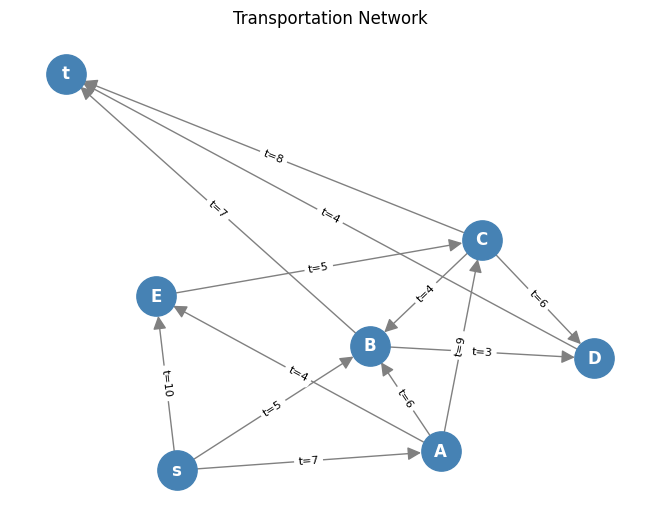

C:\Users\kpolage\AppData\Local\Temp\ipykernel_14892\3529440267.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


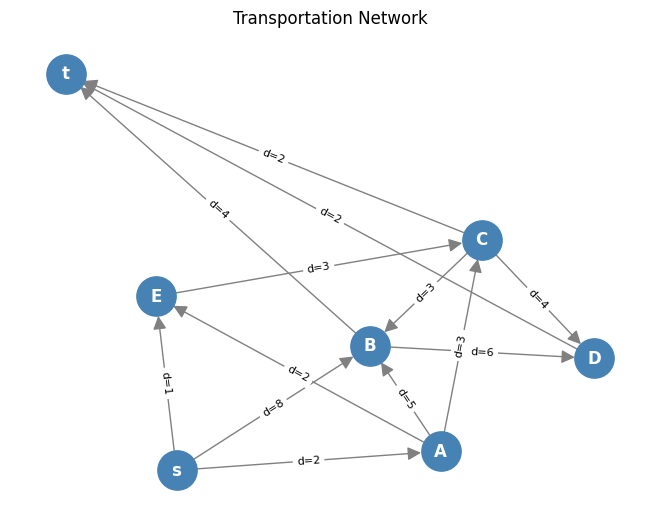

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

# Build directed graph
G = nx.DiGraph()
for (u, v), (time, distance) in network.items():
    G.add_edge(u, v, time=time, distance=distance)

# Layout
pos = nx.spring_layout(G, seed=42)

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, node_color='steelblue', 
        node_size=800, font_color='white', font_weight='bold',
        arrows=True, arrowsize=20, edge_color='gray')

# Edge labels showing travel time
time_edge_labels = {(u, v): f"t={d['time']}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=time_edge_labels, font_size=8)

plt.title("Transportation Network")
plt.tight_layout()
plt.show()


# Build directed graph
G = nx.DiGraph()
for (u, v), (time, distance) in network.items():
    G.add_edge(u, v, time=time, distance=distance)

# Layout
pos = nx.spring_layout(G, seed=42)

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, node_color='steelblue', 
        node_size=800, font_color='white', font_weight='bold',
        arrows=True, arrowsize=20, edge_color='gray')

# Edge labels showing travel time
dist_edge_labels = {(u, v): f"d={d['distance']}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=dist_edge_labels, font_size=8)

plt.title("Transportation Network")
plt.tight_layout()
plt.show()

In [10]:
import heapq

def dijkstra(network, start, end, weight):
    # priority queue: (cost, node)
    queue = [(0, start)]
    visited = {}
    predecessors = {}

    while queue:
        cost, node = heapq.heappop(queue)

        if node in visited:
            continue
        visited[node] = cost

        if node == end:
            break

        for (u, v), costs in network.items():
            if u == node:
                edge_cost = costs[0] if weight == 'time' else costs[1]
                new_cost = cost + edge_cost

                # TODO: if v not visited, push (new_cost, v) to queue
                if v not in visited:
                    heapq.heappush(queue, (new_cost, v))
                    # TODO: update predecessors[v] = node
                    if v not in predecessors or new_cost < predecessors[v][1]:
                        predecessors[v] = (node, new_cost)

    # TODO: reconstruct path by walking back through predecessors from end to start
    path = []
    current = end
    while current != start:
        path.append(current)
        current = predecessors[current][0]
    path.append(start)
    path.reverse()

    return path, visited[end]


# Find shortest time path
time_path, time_cost = dijkstra(network, 's', 't', weight='time')
print(f"Shortest time path: {' -> '.join(time_path)}, Time: {time_cost}")

# Find shortest distance path
distance_path, distance_cost = dijkstra(network, 's', 't', weight='distance')
print(f"Shortest distance path: {' -> '.join(distance_path)}, Distance: {distance_cost}")

Shortest time path: s -> B -> t, Time: 12
Shortest distance path: s -> E -> C -> t, Distance: 6


# Time Dependency

In [15]:
network_td = {
    ('s', 'A'): {'morning': 4, 'offpeak': 2, 'evening': 3, 'night': 1},
    ('s', 'B'): {'morning': 3, 'offpeak': 1, 'evening': 2, 'night': 1},
    ('s', 'E'): {'morning': 6, 'offpeak': 3, 'evening': 5, 'night': 2},
    ('A', 'C'): {'morning': 4, 'offpeak': 2, 'evening': 3, 'night': 1},
    ('A', 'B'): {'morning': 3, 'offpeak': 2, 'evening': 3, 'night': 1},
    ('A', 'E'): {'morning': 2, 'offpeak': 1, 'evening': 2, 'night': 1},
    ('B', 't'): {'morning': 4, 'offpeak': 3, 'evening': 3, 'night': 1},
    ('B', 'D'): {'morning': 2, 'offpeak': 1, 'evening': 2, 'night': 1},
    ('C', 't'): {'morning': 6, 'offpeak': 3, 'evening': 5, 'night': 2},
    ('C', 'B'): {'morning': 3, 'offpeak': 1, 'evening': 2, 'night': 1},
    ('C', 'D'): {'morning': 3, 'offpeak': 2, 'evening': 3, 'night': 1},
    ('D', 't'): {'morning': 2, 'offpeak': 1, 'evening': 2, 'night': 1},
    ('E', 'C'): {'morning': 3, 'offpeak': 1, 'evening': 2, 'night': 1},
    ('E', 'A'): {'morning': 2, 'offpeak': 1, 'evening': 2, 'night': 1},
}

def get_travel_time(link, t):
    if 6 <= t < 10:
        period = 'morning'
    elif 10 <= t < 16:
        period = 'offpeak'
    elif 16 <= t < 20:
        period = 'evening'
    else:
        period = 'night'
    return network_td[link][period]

In [16]:
def dijkstra_td(network_td, start, end, departure_time):
    # priority queue: (cost, node)
    queue = [(0, start, departure_time)]
    visited = {}
    predecessors = {}

    while queue:
        cost, node, t = heapq.heappop(queue)

        if node in visited:
            continue
        visited[node] = cost

        if node == end:
            break

        for (u, v) in network_td:
            if u == node:
                travel_time = get_travel_time((u, v), t)
                #edge_cost = costs[0] if weight == 'time' else costs[1]
                #new_cost = cost + edge_cost
                new_cost = cost + travel_time
                arrival_time = t + travel_time

                # TODO: if v not visited, push (new_cost, v) to queue
                if v not in visited:
                    heapq.heappush(queue, (new_cost, v, arrival_time))
                    # TODO: update predecessors[v] = node
                    if v not in predecessors or new_cost < predecessors[v][1]:
                        predecessors[v] = (node, new_cost)

    # TODO: reconstruct path by walking back through predecessors from end to start
    path = []
    current = end
    while current != start:
        path.append(current)
        current = predecessors[current][0]
    path.append(start)
    path.reverse()

    return path, visited[end]

for t in [6, 14, 18]:
    path, cost = dijkstra_td(network_td, 's', 't', departure_time=t)
    print(f"Departure t={t}: {' -> '.join(path)}, cost={cost}")

Departure t=6: s -> B -> D -> t, cost=6
Departure t=14: s -> B -> t, cost=4
Departure t=18: s -> B -> t, cost=3


# Backward Induction

In [18]:
## Forward induction

policy = {}

for node in G.nodes():
    for t in range(24):
        if node == 't':
            continue
        path, cost = dijkstra_td(network_td, node, 't', departure_time=t)
        print(f"From {node} at t={t}: {' -> '.join(path)}, cost={cost}")
        policy[(node, t)] = path[1] # optimal next decision from (n,t)

From s at t=0: s -> B -> t, cost=2
From s at t=1: s -> B -> t, cost=2
From s at t=2: s -> B -> t, cost=2
From s at t=3: s -> B -> t, cost=2
From s at t=4: s -> B -> t, cost=2
From s at t=5: s -> B -> t, cost=5
From s at t=6: s -> B -> D -> t, cost=6
From s at t=7: s -> B -> D -> t, cost=5
From s at t=8: s -> B -> D -> t, cost=5
From s at t=9: s -> B -> D -> t, cost=5
From s at t=10: s -> B -> D -> t, cost=3
From s at t=11: s -> B -> D -> t, cost=3
From s at t=12: s -> B -> D -> t, cost=3
From s at t=13: s -> B -> D -> t, cost=3
From s at t=14: s -> B -> t, cost=4
From s at t=15: s -> B -> t, cost=4
From s at t=16: s -> B -> t, cost=5
From s at t=17: s -> B -> t, cost=5
From s at t=18: s -> B -> t, cost=3
From s at t=19: s -> B -> t, cost=3
From s at t=20: s -> B -> t, cost=2
From s at t=21: s -> B -> t, cost=2
From s at t=22: s -> B -> t, cost=2
From s at t=23: s -> B -> t, cost=2
From A at t=0: A -> B -> t, cost=2
From A at t=1: A -> B -> t, cost=2
From A at t=2: A -> B -> t, cost=2
F

In [39]:
V = {(n,t): float('inf') for n in G.nodes() for t in range(24)}
policy2 = {}

for t in range(24):
    V[('t', t)] = 0 # boundary conditions

# Backwards induction
for _ in range(2):
    for t in range(23, -1, -1):
        for node in reversed(list(nx.topological_sort(G))):
            if node == 't': # skip terminal node
                continue
            best_cost = float('inf')
            best_next = None

            for (u, v) in G.edges():
                if u == node:
                    travel_time = get_travel_time((u,v), t)
                    arrival_time = (t + travel_time) % 24
                    cost = travel_time + V[(v, arrival_time)]
                    if cost < best_cost:
                        best_cost = cost
                        best_next = v

            V[(node, t)] = best_cost
            if best_next is not None:
                policy2[(node, t)] = best_next

In [40]:
# Check against Dijkstra's policy to make sure working for deterministic cases

mismatches = []
for (node, t), next_node in policy.items():
    if (node, t) in policy2:
        if policy2[(node, t)] != next_node:
            mismatches.append((node, t, next_node, policy2[(node, t)]))

if mismatches:
    for node, t, p1, p2 in mismatches:
        print(f"({node}, t={t}): Dijkstra={p1}, DP={p2}")
else:
    print("Policies match!")

(s, t=17): Dijkstra=B, DP=A
(A, t=13): Dijkstra=B, DP=C
(A, t=16): Dijkstra=B, DP=C


In [41]:
def extract_path(policy, start, t, max_steps=20):
    path = [start]
    node = start
    for _ in range(max_steps):
        if node == 't' or (node, t) not in policy:
            break
        next_node = policy[(node, t)]
        travel_time = get_travel_time((node, next_node), t)
        t = (t + travel_time) % 24
        path.append(next_node)
        node = next_node
    return path

In [43]:
for node, t, p1, p2 in mismatches:
    path_dijkstra = extract_path(policy, node, t)
    path_dp = extract_path(policy2, node, t)
    _, cost_d = dijkstra_td(network_td, node, 't', t)
    print(f"\n({node}, t={t}):")
    print(f"  Dijkstra: {' -> '.join(path_dijkstra)}, cost={cost_d}")
    print(f"  DP:       {' -> '.join(path_dp)}, cost={V[(node, t)]}")


(s, t=17):
  Dijkstra: s -> B -> t, cost=5
  DP:       s -> A -> B -> t, cost=5

(A, t=13):
  Dijkstra: A -> B -> t, cost=5
  DP:       A -> C -> t, cost=5

(A, t=16):
  Dijkstra: A -> B -> t, cost=6
  DP:       A -> C -> B -> t, cost=6


# Stochastic Travel Times

In [44]:
stochastic_network = {
    ('s', 'A'): {
        'morning': [(2, 0.25), (4, 0.50), (6, 0.25)], # (travel time, probability)
        'offpeak': [(1, 0.25), (2, 0.50), (3, 0.25)],
        'evening': [(2, 0.25), (3, 0.50), (5, 0.25)],
        'night':   [(1, 0.50), (2, 0.50)],
    },
    ('s', 'B'): {
        'morning': [(1, 0.25), (3, 0.50), (5, 0.25)],
        'offpeak': [(1, 0.50), (2, 0.50)],
        'evening': [(1, 0.25), (2, 0.50), (4, 0.25)],
        'night':   [(1, 0.75), (2, 0.25)],
    },
    ('s', 'E'): {
        'morning': [(3, 0.25), (6, 0.50), (9, 0.25)],
        'offpeak': [(2, 0.25), (3, 0.50), (4, 0.25)],
        'evening': [(3, 0.25), (5, 0.50), (7, 0.25)],
        'night':   [(1, 0.50), (2, 0.50)],
    },
    ('A', 'C'): {
        'morning': [(2, 0.25), (4, 0.50), (6, 0.25)],
        'offpeak': [(1, 0.25), (2, 0.50), (3, 0.25)],
        'evening': [(2, 0.25), (3, 0.50), (5, 0.25)],
        'night':   [(1, 0.50), (2, 0.50)],
    },
    ('A', 'B'): {
        'morning': [(1, 0.25), (3, 0.50), (5, 0.25)],
        'offpeak': [(1, 0.25), (2, 0.50), (3, 0.25)],
        'evening': [(1, 0.25), (3, 0.50), (4, 0.25)],
        'night':   [(1, 0.75), (2, 0.25)],
    },
    ('A', 'E'): {
        'morning': [(1, 0.25), (2, 0.50), (4, 0.25)],
        'offpeak': [(1, 0.50), (2, 0.50)],
        'evening': [(1, 0.25), (2, 0.50), (3, 0.25)],
        'night':   [(1, 0.75), (2, 0.25)],
    },
    ('B', 't'): {
        'morning': [(2, 0.25), (4, 0.50), (6, 0.25)],
        'offpeak': [(1, 0.25), (2, 0.50), (3, 0.25)],
        'evening': [(2, 0.25), (3, 0.50), (5, 0.25)],
        'night':   [(1, 0.50), (2, 0.50)],
    },
    ('B', 'D'): {
        'morning': [(1, 0.25), (2, 0.50), (4, 0.25)],
        'offpeak': [(1, 0.50), (2, 0.50)],
        'evening': [(1, 0.25), (2, 0.50), (3, 0.25)],
        'night':   [(1, 0.75), (2, 0.25)],
    },
    ('C', 't'): {
        'morning': [(3, 0.25), (6, 0.50), (9, 0.25)],
        'offpeak': [(2, 0.25), (3, 0.50), (4, 0.25)],
        'evening': [(3, 0.25), (5, 0.50), (7, 0.25)],
        'night':   [(1, 0.50), (2, 0.50)],
    },
    ('C', 'B'): {
        'morning': [(1, 0.25), (3, 0.50), (5, 0.25)],
        'offpeak': [(1, 0.50), (2, 0.50)],
        'evening': [(1, 0.25), (2, 0.50), (4, 0.25)],
        'night':   [(1, 0.75), (2, 0.25)],
    },
    ('C', 'D'): {
        'morning': [(1, 0.25), (3, 0.50), (5, 0.25)],
        'offpeak': [(1, 0.25), (2, 0.50), (3, 0.25)],
        'evening': [(2, 0.25), (3, 0.50), (4, 0.25)],
        'night':   [(1, 0.75), (2, 0.25)],
    },
    ('D', 't'): {
        'morning': [(1, 0.25), (2, 0.50), (4, 0.25)],
        'offpeak': [(1, 0.50), (2, 0.50)],
        'evening': [(1, 0.25), (2, 0.50), (3, 0.25)],
        'night':   [(1, 0.75), (2, 0.25)],
    },
    ('E', 'C'): {
        'morning': [(1, 0.25), (3, 0.50), (5, 0.25)],
        'offpeak': [(1, 0.50), (2, 0.50)],
        'evening': [(1, 0.25), (2, 0.50), (4, 0.25)],
        'night':   [(1, 0.75), (2, 0.25)],
    },
    ('E', 'A'): {
        'morning': [(1, 0.25), (2, 0.50), (4, 0.25)],
        'offpeak': [(1, 0.50), (2, 0.50)],
        'evening': [(1, 0.25), (2, 0.50), (3, 0.25)],
        'night':   [(1, 0.75), (2, 0.25)],
    },
}

In [47]:
def get_stochastic_travel_time(link, t):
    if 6 <= t < 10:
        period = 'morning'
    elif 10 <= t < 16:
        period = 'offpeak'
    elif 16 <= t < 20:
        period = 'evening'
    else:
        period = 'night'
    
    travel_times, probabilities = zip(*stochastic_network[link][period])
    return np.random.choice(travel_times, p=probabilities)


def expected_cost(link, t, V, v):
    if 6 <= t < 10:
        period = 'morning'
    elif 10 <= t < 16:
        period = 'offpeak'
    elif 16 <= t < 20:
        period = 'evening'
    else:
        period = 'night'
        
    travel_times, probabilities = zip(*stochastic_network[link][period])
    expected_cost = 0
    for travel_time, prob in zip(travel_times, probabilities):
        arrival_time = (t + travel_time) % 24
        expected_cost += prob * (travel_time + V[(v, arrival_time)]) # value iteration update, loop acts as sum
    return expected_cost

In [ ]:
V_s = {(n, t): float('inf') for n in G.nodes() for t in range(24)}
policy_s = {}

for t in range(24):
    V_s[('t', t)] = 0

for _ in range(2): # to go back and cover initial runs without connections to terminus
    for t in range(23, -1, -1):
        for node in reversed(list(nx.topological_sort(G))):
            if node == 't':
                continue
            best_cost = float('inf')
            best_next = None

            for (u, v) in G.edges():
                if u == node:
                    cost = expected_cost((u, v), t, V_s, v)
                    if cost < best_cost:
                        best_cost = cost
                        best_next = v

            V_s[(node, t)] = best_cost
            if best_next is not None:
                policy_s[(node, t)] = best_next

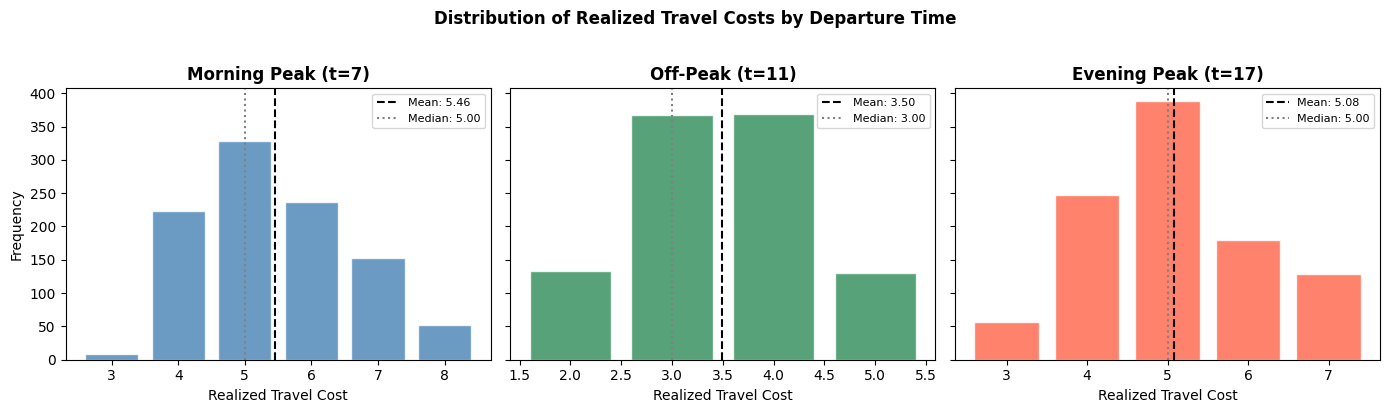

Departure           Mean      Std      Min      Max
-----------------------------------------------
Morning Peak (t=7)     5.46     1.17        3        8
Off-Peak (t=11)     3.50     0.88        2        5
Evening Peak (t=17)     5.08     1.08        3        7


In [77]:
def simulate_trip(policy, start, t):
    path = [start]
    node = start
    time = t
    total_cost = 0

    while node != 't':
        next_node = policy.get((node, time % 24), None)
        path.append(next_node)
        travel_time = get_stochastic_travel_time((node, next_node), time % 24)
        total_cost += travel_time
        time += travel_time
        node = next_node

    return path, total_cost


departure_times = [7, 11, 17]
n = 1000

results = {}
for t in departure_times:
    costs = []
    paths = []
    for _ in range(n):
        path, cost = simulate_trip(policy_s, 's', t)
        costs.append(cost)
        paths.append('->'.join(path))
    results[t] = {'costs': costs, 'paths': paths}



fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

colors = ['steelblue', 'seagreen', 'tomato']
labels = ['Morning Peak (t=7)', 'Off-Peak (t=11)', 'Evening Peak (t=17)']

for ax, (t, color, label) in zip(axes, zip(departure_times, colors, labels)):
    costs = results[t]['costs']
    bins = range(min(costs), max(costs) + 2) # integer bins
    ax.hist(costs, bins=bins, align='left', rwidth=0.8, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(costs), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(costs):.2f}')
    ax.axvline(np.median(costs), color='gray', linestyle=':', linewidth=1.5, label=f'Median: {np.median(costs):.2f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Realized Travel Cost')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Frequency')
fig.suptitle('Distribution of Realized Travel Costs by Departure Time', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# summary stats
print(f"{'Departure':<15} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 47)
for t, label in zip(departure_times, labels):
    costs = results[t]['costs']
    print(f"{label:<15} {np.mean(costs):>8.2f} {np.std(costs):>8.2f} {np.min(costs):>8} {np.max(costs):>8}")

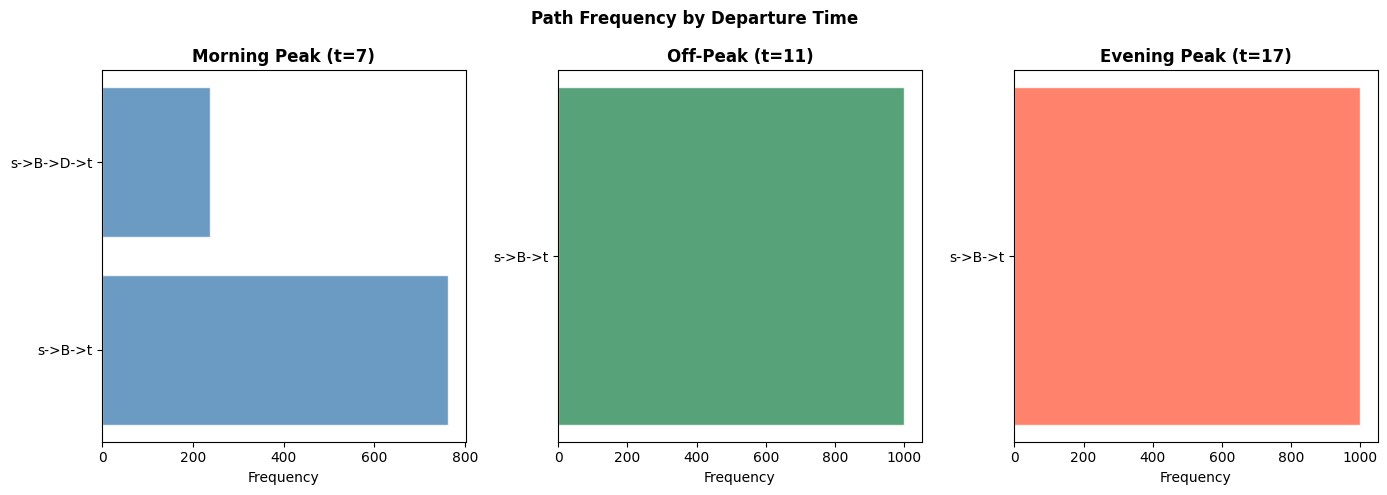

In [78]:
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (t, color, label) in zip(axes, zip(departure_times, colors, labels)):
    path_counts = Counter(results[t]['paths'])
    paths, counts = zip(*sorted(path_counts.items(), key=lambda x: -x[1]))
    ax.barh(paths, counts, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Frequency')

fig.suptitle('Path Frequency by Departure Time', fontweight='bold')
plt.tight_layout()
plt.show()

In [80]:
def get_mean(base_mean, t):
    # smooth congestion curve: peaks at t=8 (morning) and t=17 (evening)
    congestion = 1 + 0.5 * (np.exp(-0.5*((t-8)/2)**2) + 0.7*np.exp(-0.5*((t-17)/2)**2))
    return base_mean * congestion

def get_std(base_std, t):
    # variance also higher during peak hours
    congestion = 1 + 0.3 * (np.exp(-0.5*((t-8)/2)**2) + 0.7*np.exp(-0.5*((t-17)/2)**2))
    return base_std * congestion

def get_stochastic_travel_time(link, t):
    base_mean, base_std = stochastic_network[link]
    mean = get_mean(base_mean, t)
    std = get_std(base_std, t)
    return max(1, np.random.normal(mean, std))

In [84]:
# (base_mean, base_std) representing free-flow travel time
# higher mean = longer link, higher std = more variable
network_params = {
    ('s', 'A'): (2, 0.5),
    ('s', 'B'): (1, 0.3),
    ('s', 'C'): (3, 0.8),
    ('A', 'D'): (2, 0.6),
    ('A', 'E'): (1, 0.4),
    ('B', 'D'): (2, 0.5),
    ('B', 'F'): (3, 0.7),
    ('C', 'F'): (1, 0.3),
    ('C', 'G'): (2, 0.5),
    ('D', 'H'): (2, 0.4),
    ('D', 'I'): (3, 0.8),
    ('E', 'H'): (1, 0.3),
    ('E', 'I'): (2, 0.5),
    ('F', 'G'): (1, 0.4),
    ('F', 'J'): (2, 0.6),
    ('G', 'J'): (3, 0.7),
    ('G', 'K'): (1, 0.3),
    ('H', 'L'): (2, 0.5),
    ('H', 'M'): (1, 0.4),
    ('I', 'L'): (1, 0.3),
    ('I', 'M'): (2, 0.6),
    ('J', 'K'): (2, 0.5),
    ('J', 'N'): (3, 0.7),
    ('K', 'N'): (1, 0.3),
    ('K', 't'): (2, 0.5),
    ('L', 'N'): (2, 0.4),
    ('L', 't'): (3, 0.8),
    ('M', 'N'): (1, 0.3),
    ('M', 't'): (2, 0.5),
    ('N', 't'): (1, 0.3),
}

C:\Users\kpolage\AppData\Local\Temp\ipykernel_14892\122996531.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


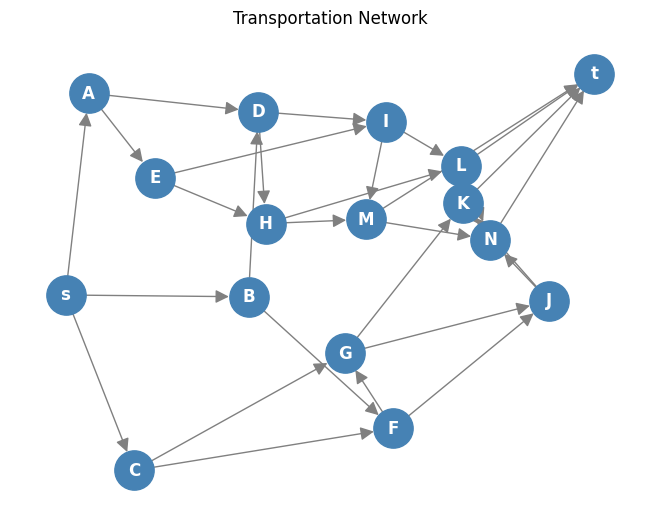

In [87]:
G = nx.DiGraph()
for (u, v) in network_params:
    G.add_edge(u, v)

pos = nx.spring_layout(G, seed=42)

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, node_color='steelblue', 
        node_size=800, font_color='white', font_weight='bold',
        arrows=True, arrowsize=20, edge_color='gray')

# Edge labels showing travel time
#dist_edge_labels = {(u, v): f"d={d['distance']}" for u, v, d in G.edges(data=True)}
#nx.draw_networkx_edge_labels(G, pos, edge_labels=dist_edge_labels, font_size=8)

plt.title("Transportation Network")
plt.tight_layout()
plt.show()

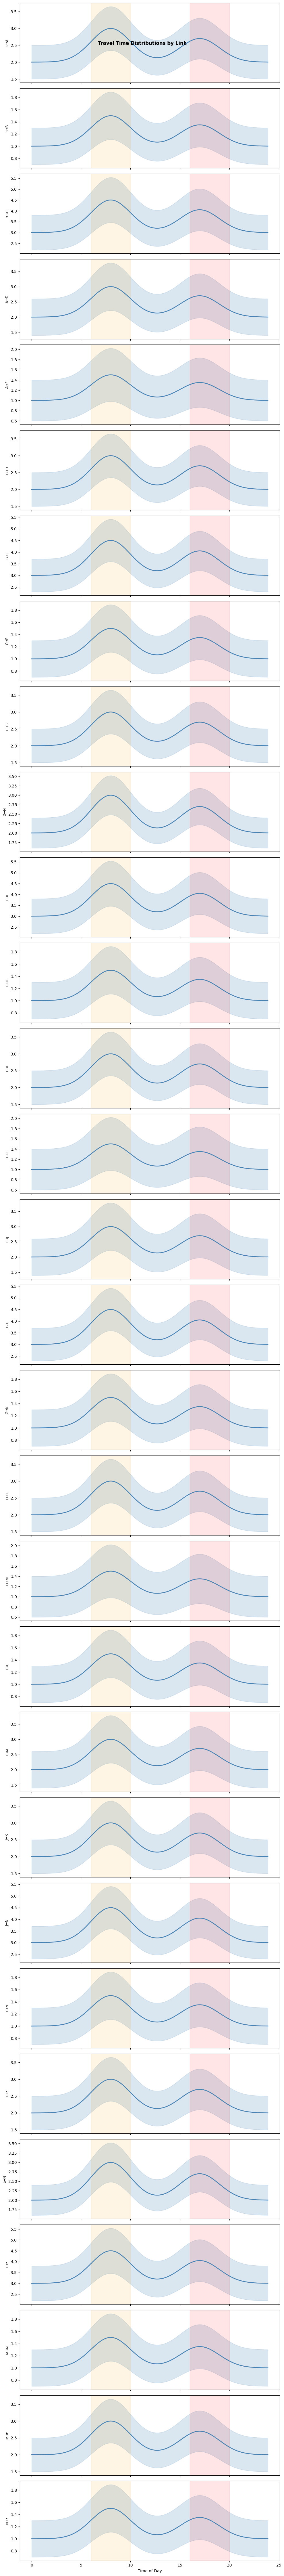

In [88]:
links_to_plot = list(network_params.keys())
t_values = np.arange(0, 24, 0.1)

fig, axes = plt.subplots(len(links_to_plot), 1, figsize=(10, 3*len(links_to_plot)), sharex=True)

for ax, link in zip(axes, links_to_plot):
    base_mean, base_std = network_params[link]
    means = [get_mean(base_mean, t) for t in t_values]
    stds = [get_std(base_std, t) for t in t_values]

    ax.plot(t_values, means, color='steelblue', linewidth=2)
    ax.fill_between(t_values,
                    [m - s for m, s in zip(means, stds)],
                    [m + s for m, s in zip(means, stds)],
                    alpha=0.2, color='steelblue')
    ax.axvspan(6, 10, alpha=0.1, color='orange')
    ax.axvspan(16, 20, alpha=0.1, color='red')
    ax.set_ylabel(f"{link[0]}→{link[1]}", fontsize=9)

axes[-1].set_xlabel('Time of Day')
fig.suptitle('Travel Time Distributions by Link', fontweight='bold')
plt.tight_layout()
plt.show()